#### Importing The Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import matplotlib.pyplot as plt

#### Loading The Data

In [2]:
bankruptcy= pd.read_csv('american_bankruptcy.csv')
# dataset page: https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset

<class 'pandas.DataFrame'>
RangeIndex: 78682 entries, 0 to 78681
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  78682 non-null  str    
 1   status_label  78682 non-null  str    
 2   year          78682 non-null  int64  
 3   X1            78682 non-null  float64
 4   X2            78682 non-null  float64
 5   X3            78682 non-null  float64
 6   X4            78682 non-null  float64
 7   X5            78682 non-null  float64
 8   X6            78682 non-null  float64
 9   X7            78682 non-null  float64
 10  X8            78682 non-null  float64
 11  X9            78682 non-null  float64
 12  X10           78682 non-null  float64
 13  X11           78682 non-null  float64
 14  X12           78682 non-null  float64
 15  X13           78682 non-null  float64
 16  X14           78682 non-null  float64
 17  X15           78682 non-null  float64
 18  X16           78682 non-null  float64

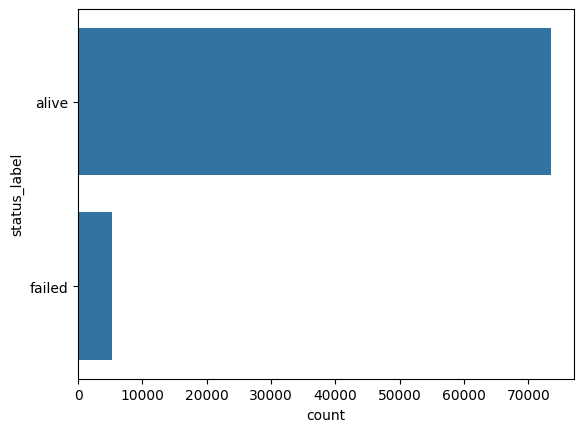

In [3]:
bankruptcy.info()
bankruptcy.head()
sns.countplot(y=bankruptcy['status_label'])
print(bankruptcy["year"].min())
print(bankruptcy["year"].max())

#### Preprocessing

In [4]:
decision = {"alive": 0, "failed": 1}

bankruptcy_copy = bankruptcy.copy()

bankruptcy_copy["status_label"] = bankruptcy_copy["status_label"].map(decision)
# print(bankruptcy_copy.groupby("year")["status_label"].mean())


# X = bankruptcy_copy.drop(columns = ["status_label", "company_name", "year"])
# y = bankruptcy_copy["status_label"]

# from the documentation of the data, the best way to split the data is to do it by the years below, instead of using train_test_split.


train = bankruptcy_copy[bankruptcy_copy["year"] <= 2011]

validation = bankruptcy_copy[
    (bankruptcy_copy["year"] >= 2012) &
    (bankruptcy_copy["year"] <= 2014)
]

test = bankruptcy_copy[bankruptcy_copy["year"] >= 2015]

X_train = train.drop(columns=["status_label", "company_name", "year"])
y_train = train["status_label"]

X_val = validation.drop(columns=["status_label", "company_name", "year"])
y_val = validation["status_label"]

X_test = test.drop(columns=["status_label", "company_name", "year"])
y_test = test["status_label"]

In [5]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("Training failures:", y_train.sum())
print("Validation failures:", y_val.sum())
print("Test failures:", y_test.sum())

Training: (55927, 18)
Validation: (10473, 18)
Test: (12282, 18)
Training failures: 4442
Validation failures: 491
Test failures: 287


#### Creating our Main Model to be Compared (RandomForestClassifier)

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

calibrated_rf = CalibratedClassifierCV(
    rf,
    method="sigmoid",
    cv=5
)

calibrated_rf.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...t 0x11a77aba0>, <sk

In [7]:
# Get calibrated probabilities on validation data
val_probs = calibrated_rf.predict_proba(X_val)[:, 1]

val_bs = brier_score_loss(y_val, val_probs)
val_auc = roc_auc_score(y_val, val_probs)
val_log_loss = log_loss(y_val, val_probs)

print("Validation Brier Score:",
      val_bs)

print("Validation ROC-AUC:",
      val_auc)

print("Validation Log Loss:",
      val_log_loss)

Validation Brier Score: 0.040542316349207755
Validation ROC-AUC: 0.8671838433416401
Validation Log Loss: 0.17020174553242814


### Comparing Our Model to a Baseline

In [8]:
# 1. Calculate the bankruptcy rate in the training data
baseline_prob = y_train.mean()

print("Training bankruptcy rate:", baseline_prob)


# 2. Predict that same probability for every validation company
baseline_probs = np.full(
    len(y_val),
    baseline_prob
)


# 3. Evaluate the baseline
baseline_brier = brier_score_loss(
    y_val,
    baseline_probs
)

baseline_logloss = log_loss(
    y_val,
    baseline_probs
)


print("\nBaseline Results")
print("----------------")
print("Brier Score:", baseline_brier)
print("Log Loss:", baseline_logloss)


# 5. Calculate improvement
brier_improvement = (
    (baseline_brier - val_bs)
    / baseline_brier
) * 100

logloss_improvement = (
    (baseline_logloss - val_log_loss)
    / baseline_logloss
) * 100

print("\nImprovement over baseline")
print("-------------------------")
print(f"Brier Score improvement: {brier_improvement:.2f}%")
print(f"Log Loss improvement: {logloss_improvement:.2f}%")

Training bankruptcy rate: 0.07942496468610867

Baseline Results
----------------
Brier Score: 0.04574350926806231
Log Loss: 0.1976275016845814

Improvement over baseline
-------------------------
Brier Score improvement: 11.37%
Log Loss improvement: 13.88%


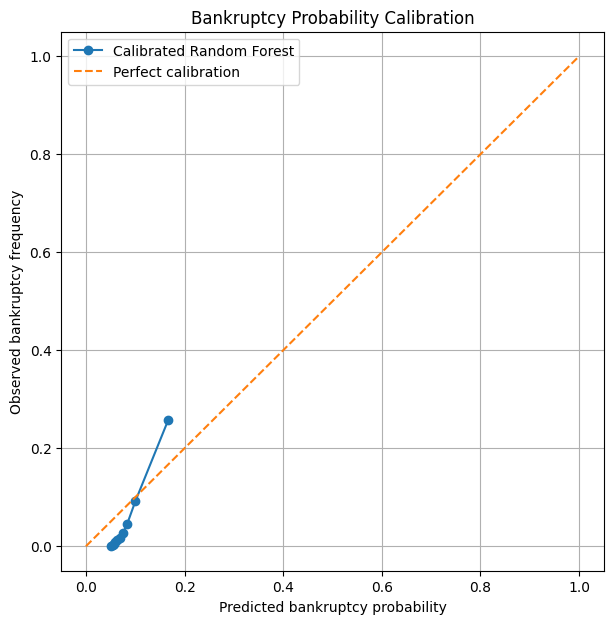

In [9]:
prob_true, prob_pred = calibration_curve(
    y_val,
    val_probs,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Calibrated Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Predicted bankruptcy probability")
plt.ylabel("Observed bankruptcy frequency")
plt.title("Bankruptcy Probability Calibration")
plt.legend()
plt.grid()
plt.show()

In [10]:
sigmoid_calibrated_rf = CalibratedClassifierCV(
    rf,
    method="isotonic",
    cv=5
)

sigmoid_calibrated_rf.fit(X_train, y_train)

isotonic_probs = sigmoid_calibrated_rf.predict_proba(X_val)[:, 1]

isotonic_bs = brier_score_loss(y_val, isotonic_probs)
isotonic_auc = roc_auc_score(y_val, isotonic_probs)
isotonic_log_loss = log_loss(y_val, isotonic_probs)


# Compare with sigmoid results
print("Sigmoid Brier Score:", val_bs)

print("Sigmoid ROC-AUC:", val_auc)

print("Sigmoid Log Loss:", val_log_loss)


print("\nIsotonic Brier Score:", isotonic_bs)

print("Isotonic ROC-AUC:", isotonic_auc)

print("Isotonic Log Loss:", isotonic_log_loss)


Sigmoid Brier Score: 0.040542316349207755
Sigmoid ROC-AUC: 0.8671838433416401
Sigmoid Log Loss: 0.17020174553242814

Isotonic Brier Score: 0.041479506510161177
Isotonic ROC-AUC: 0.8664559547307353
Isotonic Log Loss: 0.16833682953365672


#### Tuning Hyperparameters

In [11]:
tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/harisissah/Documents/Ashesi/ai_labs/ai_env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harisissah/Documents/Ashesi/ai_labs/ai_env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harisissah/Documents/Ashesi/ai_labs/ai_env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warning

Best parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample'}

Best CV ROC-AUC:
0.6558452637107427


In [12]:
best_rf = random_search.best_estimator_

val_probs_raw = best_rf.predict_proba(X_val)[:, 1]

print(
    "Validation ROC-AUC:",
    roc_auc_score(y_val, val_probs_raw)
)

Validation ROC-AUC: 0.863166326679265


In [13]:
calibrated_rf = CalibratedClassifierCV(
    best_rf,
    method="sigmoid",
    cv=5
)

calibrated_rf.fit(X_train, y_train)

val_probs = calibrated_rf.predict_proba(X_val)[:, 1]

print("Calibrated Validation ROC-AUC:",
      roc_auc_score(y_val, val_probs))

print("Calibrated Validation Brier Score:",
      brier_score_loss(y_val, val_probs))

print("Calibrated Validation Log Loss:",
      log_loss(y_val, val_probs))

Calibrated Validation ROC-AUC: 0.8614746870231996
Calibrated Validation Brier Score: 0.04050282761175109
Calibrated Validation Log Loss: 0.16684776605717094


#### Locking In Final Values

In [14]:
final_rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=10,
    max_features="log2",
    max_depth=None,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

final_model = CalibratedClassifierCV(
    final_rf,
    method="sigmoid",
    cv=5
)

final_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...t 0x11b504c50>, <sk

In [15]:
test_probs = final_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:",
      roc_auc_score(y_test, test_probs))

print("Test Brier Score:",
      brier_score_loss(y_test, test_probs))

print("Test Log Loss:",
      log_loss(y_test, test_probs))

Test ROC-AUC: 0.8364588613432137
Test Brier Score: 0.02471109905667813
Test Log Loss: 0.12727586978149724


#### Testing Our Final Model Against a Baseline

In [16]:
baseline_prob = y_train.mean()

test_baseline_probs = np.full(
    len(y_test),
    baseline_prob
)

baseline_brier = brier_score_loss(
    y_test,
    test_baseline_probs
)

baseline_logloss = log_loss(
    y_test,
    test_baseline_probs
)

print("Test Baseline Brier:", baseline_brier)
print("Test Baseline Log Loss:", baseline_logloss)

print("\nImprovement")

print(
    "Brier improvement:",
    f"{((baseline_brier - brier_score_loss(y_test, test_probs))
       / baseline_brier) * 100:.2f}%"
)

print(
    "Log Loss improvement:",
    f"{((baseline_logloss - log_loss(y_test, test_probs))
       / baseline_logloss) * 100:.2f}%"
)

Test Baseline Brier: 0.025963924288323465
Test Baseline Log Loss: 0.14001155478376506

Improvement
Brier improvement: 4.83%
Log Loss improvement: 9.10%


Maybe you need to draw a confusion matrix for this.

In [18]:
import joblib

feature_columns = X_train.columns.tolist()

joblib.dump(final_model, 'final_rf_calibrated.pkl')
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']